# 06 — Synthetic benchmark v0.1: fidelity validation

Compares the `central_provisional` pilot's `observed_notices` against the
real BOAMP corpus's calibration tables
(`reports/tables/synthetic_calibration/`), then runs the *existing*
production Layer 1 candidate-generation code
(`boamp.linkage.candidates.generate_pairs_single_key`) on the synthetic
`observed_notices` (via a thin adapter,
`boamp.synthetic.compatibility.adapt_observed_notices_to_sources`) so
candidate-count statistics — an emergent property, never assigned during
generation — can be compared directly.

Per spec, this is diagnostic only: no linkage accuracy claim is made here
(Phase 12), and no synthetic-generation parameter is retuned to make a
preferred linkage method "win".


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from boamp.config import load_config
from boamp.reporting.figures import setup_style
from boamp.synthetic.compatibility import adapt_observed_notices_to_sources
from boamp.linkage.candidates import generate_pairs_single_key

cfg = load_config(PROJECT_ROOT)
setup_style()

TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "synthetic_benchmark" / "v0_1"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "synthetic_benchmark" / "v0_1"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CALIB_DIR = PROJECT_ROOT / "reports" / "tables" / "synthetic_calibration"

SCENARIO = "central_provisional"
PILOT_DIR = PROJECT_ROOT / "data/processed/synthetic_benchmark/v0_1_provisional" / SCENARIO / "world_001/corruption_001"
observed = pd.read_parquet(PILOT_DIR / "observed_notices.parquet")
clean = pd.read_parquet(PILOT_DIR / "clean_notices.parquet")
buyers = pd.read_parquet(PILOT_DIR / "latent_buyers.parquet")
establishments = pd.read_parquet(PILOT_DIR / "latent_establishments.parquet")
print(f"Loaded {SCENARIO} pilot: {len(observed)} observed notices, {len(buyers)} buyers")

Loaded central_provisional pilot: 9534 observed notices, 2000 buyers


## 1. Volume and schema composition

In [2]:
fidelity_rows = []

def add_fidelity(dimension, real_value, synthetic_value, note=""):
    fidelity_rows.append(dict(dimension=dimension, real_value=real_value,
                               synthetic_value=synthetic_value, note=note))

real_schema_mix = pd.read_csv(CALIB_DIR / "parameter_inventory.csv").set_index("parameter_name").loc["schema_family_mix", "estimate_or_range"]
syn_schema_mix = observed["schema_family"].value_counts(normalize=True).round(3).to_dict()
add_fidelity("schema_family_mix", real_schema_mix, syn_schema_mix)
print("real: ", real_schema_mix)
print("synthetic:", syn_schema_mix)

real:  LEGACY=87.4%; EFORMS=12.6%
synthetic: {'LEGACY': 0.726, 'EFORMS': 0.274}


In [3]:
real_notice_type_mix = pd.read_csv(CALIB_DIR / "parameter_inventory.csv").set_index("parameter_name").loc["notice_type_mix", "estimate_or_range"]
syn_notice_type_mix = observed["notice_type_normalized"].value_counts(normalize=True).round(3).to_dict()
add_fidelity("notice_type_mix", real_notice_type_mix, syn_notice_type_mix)
print("real: ", real_notice_type_mix)
print("synthetic:", syn_notice_type_mix)

real:  APPEL_OFFRE=68.9%; ATTRIBUTION=26.7%; OTHER=4.5%
synthetic: {'APPEL_OFFRE': 0.725, 'ATTRIBUTION': 0.275}


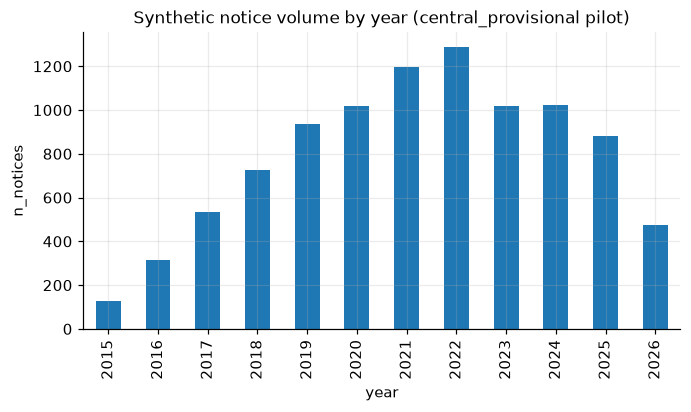

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
observed.assign(year=observed["publication_date"].dt.year)["year"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title(f"Synthetic notice volume by year ({SCENARIO} pilot)")
ax.set_xlabel("year"); ax.set_ylabel("n_notices")
fig.savefig(FIG_DIR / "v0_1_volume_by_year.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "v0_1_volume_by_year.pdf", bbox_inches="tight")
plt.show()

## 2. Buyer activity / concentration

In [5]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    cum = np.cumsum(x)
    return (n + 1 - 2 * (cum.sum() / cum[-1])) / n

real_gini = 0.832  # calib_buyer_concentration_lorenz.csv / parameter_inventory.csv (real corpus, n=5,268 buyers)
syn_gini = gini(buyers["activity_rate"])
add_fidelity("buyer_activity_gini", real_gini, round(syn_gini, 3),
             "real corpus n=5,268 buyers vs synthetic pilot n=2,000-equivalent-scale buyers (see generate_pilot n_buyers)")
print(f"real Gini = {real_gini}, synthetic Gini = {syn_gini:.3f}")

real Gini = 0.832, synthetic Gini = 0.814


In [6]:
establishments_per_buyer = establishments.groupby("buyer_id_true").size()
add_fidelity("establishments_per_buyer_mean", "n/a (not a real-corpus OBSERVABLE table)", round(establishments_per_buyer.mean(), 2),
             "no directly comparable real-corpus table exists (BOAMP does not expose a buyer->establishment hierarchy natively); reported for internal consistency only")
establishments_per_buyer.describe()

count    2000.000000
mean        1.087000
std         0.327849
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
dtype: float64

## 3. Identifier availability

In [7]:
real_siret_share = 0.272  # parameter_inventory.csv#siret_vs_name_fallback_share
syn_siret_share = observed["buyer_siret_raw"].notna().mean()
add_fidelity("siret_present_share", real_siret_share, round(syn_siret_share, 3))
print(f"real SIRET-present share = {real_siret_share}, synthetic = {syn_siret_share:.3f}")

real SIRET-present share = 0.272, synthetic = 0.412


## 4. CPV quality

In [8]:
real_cpv_missing = 0.1706
syn_cpv_missing = observed["cpv_clean"].isna().mean()
add_fidelity("cpv_missing_rate", real_cpv_missing, round(syn_cpv_missing, 3))

real_cpv_generic = 0.0714
syn_cpv_generic = (observed["cpv_clean"].fillna("").str[2:] == "000000").mean()
add_fidelity("cpv_generic_rate_among_present", real_cpv_generic, round(syn_cpv_generic, 3))
print(f"real cpv_missing={real_cpv_missing}, synthetic={syn_cpv_missing:.3f}")
print(f"real cpv_generic={real_cpv_generic}, synthetic~={syn_cpv_generic:.3f} (marginal, not among-present)")

real cpv_missing=0.1706, synthetic=0.170
real cpv_generic=0.0714, synthetic~=0.088 (marginal, not among-present)


## 5. Duration availability

In [9]:
real_duration_present = 0.1365
syn_duration_present = observed["declared_duration_months"].notna().mean()
add_fidelity("duration_present_rate", real_duration_present, round(syn_duration_present, 3))
print(f"real={real_duration_present}, synthetic={syn_duration_present:.3f}")

real=0.1365, synthetic=0.324


## 6. Text length and exact duplication

In [10]:
real_median_len = 98.0
syn_median_len = observed["objet_clean"].dropna().map(len).median()
add_fidelity("median_text_length_chars", real_median_len, syn_median_len)

real_dup_rate = 0.5143
syn_dup_rate = 1 - (observed["objet_clean"].dropna().nunique() / observed["objet_clean"].notna().sum())
add_fidelity("exact_duplicate_template_rate", real_dup_rate, round(syn_dup_rate, 3))
print(f"median length: real={real_median_len} synthetic={syn_median_len}")
print(f"exact-duplicate rate: real={real_dup_rate} synthetic={syn_dup_rate:.3f}")

median length: real=98.0 synthetic=120.0
exact-duplicate rate: real=0.5143 synthetic=0.281


## 7. Missingness co-occurrence (dependent corruption check)

In [11]:
missing_flags = pd.DataFrame({
    "identifier_missing": observed["buyer_siret_raw"].isna() & observed["buyer_siren_raw"].isna(),
    "cpv_missing": observed["cpv_clean"].isna(),
    "duration_missing": observed["declared_duration_months"].isna(),
})
phi = missing_flags.astype(int).corr()
add_fidelity("missingness_phi_identifier_cpv", "see calib_missingness_phi_matrix.csv (real)",
             round(phi.loc["identifier_missing", "cpv_missing"], 3),
             "positive correlation here evidences the latent quality-class dependent-corruption mechanism (missingness.py)")
phi

,identifier_missing,cpv_missing,duration_missing
identifier_missing,1.000000,0.121423,0.282120
cpv_missing,0.121423,1.000000,0.148154
duration_missing,0.282120,0.148154,1.000000


## 8. Notice-family size

In [12]:
fam = pd.read_parquet(PILOT_DIR / "notice_family_membership.parquet")
fam_size = fam.groupby("cycle_id_true").size()
real_fam_note = "see notice_family_size_distribution.csv (real, provisional-family-based)"
add_fidelity("notice_family_size_mean", real_fam_note, round(fam_size.mean(), 2))
fam_size.value_counts().sort_index()

1    4294
2    2620
Name: count, dtype: int64

## 9. Candidate-environment fidelity (Phase 12 compatibility check)

Runs the **existing, unmodified** Layer 1 candidate-generation code on the
synthetic `observed_notices` (via a thin schema adapter) so candidate-count
statistics — an emergent output, never set during generation — can be
compared to the real corpus's own candidate-environment numbers. This
proves the production linkage code can consume `observed_notices.parquet`
and gives a first-pass fidelity read; it is **not** a linkage-accuracy
claim (no synthetic ground truth is used by the candidate generator, and no
generator parameter is tuned based on this result).


In [13]:
sources_adapted = adapt_observed_notices_to_sources(observed)
pairs, window_months = generate_pairs_single_key(sources_adapted, cfg, verbose=True)

cand_per_source = pairs[pairs["candidate_rank"] == 1]["n_candidates_for_source"]
n_eligible = (sources_adapted["buyer_key_type"] != "MISSING").sum()
n_with_candidates = pairs["source_notice_id"].nunique()
zero_candidate_rate = 1 - (n_with_candidates / n_eligible)

print(f"window_months used: {window_months}")
print(f"eligible sources (buyer_key present): {n_eligible}")
print(f"sources with >=1 candidate: {n_with_candidates}")
print(f"synthetic zero-candidate rate: {zero_candidate_rate:.1%}  (real corpus, USE_AS_FIDELITY_TARGET: 60.9%)")
print(f"synthetic candidates-per-source median/p90: {cand_per_source.median():.0f} / {cand_per_source.quantile(0.9):.0f}  "
      f"(real corpus: median=3, p90=12)")

add_fidelity("zero_candidate_source_rate", 0.609, round(zero_candidate_rate, 3),
             "real value is Layer 1 production (algorithm-conditioned); synthetic value uses the same production candidate-generation code on synthetic data, per Phase 9/12")
add_fidelity("candidates_per_source_median", 3, round(cand_per_source.median()))
add_fidelity("candidates_per_source_p90", 12, round(cand_per_source.quantile(0.9)))

Eligible sources: 9534; median observed duration 12.0m -> temporal window 6m
Generated 29821 Layer 1 candidate pairs (3399 sources with >=1 candidate)
window_months used: 6
eligible sources (buyer_key present): 9534
sources with >=1 candidate: 3399
synthetic zero-candidate rate: 64.3%  (real corpus, USE_AS_FIDELITY_TARGET: 60.9%)
synthetic candidates-per-source median/p90: 2 / 29  (real corpus: median=3, p90=12)


## 10. Export fidelity tables and figures

In [14]:
fidelity_df = pd.DataFrame(fidelity_rows)
fidelity_df.to_csv(TABLES_DIR / "v0_1_fidelity_summary.csv", index=False)
fidelity_df

,dimension,real_value,synthetic_value,note
0,schema_family_mix,LEGACY=87.4%; EFORMS=12.6%,"{'LEGACY': 0.726, 'EFORMS': 0.274}",
1,notice_type_mix,APPEL_OFFRE=68.9%; ATTRIBUTION=26.7%; OTHER=4.5%,"{'APPEL_OFFRE': 0.725, 'ATTRIBUTION': 0.275}",
2,buyer_activity_gini,0.832,0.814,"real corpus n=5,268 buyers vs synthetic pilot ..."
3,establishments_per_buyer_mean,n/a (not a real-corpus OBSERVABLE table),1.09,no directly comparable real-corpus table exist...
4,siret_present_share,0.272,0.412,
5,cpv_missing_rate,0.1706,0.17,
6,cpv_generic_rate_among_present,0.0714,0.088,
7,duration_present_rate,0.1365,0.324,
8,median_text_length_chars,98.0,120.0,
9,exact_duplicate_template_rate,0.5143,0.281,


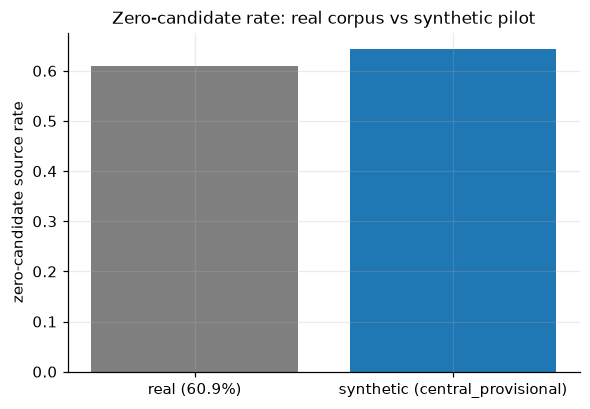

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["real (60.9%)", f"synthetic ({SCENARIO})"], [0.609, zero_candidate_rate], color=["tab:gray", "tab:blue"])
ax.set_ylabel("zero-candidate source rate")
ax.set_title("Zero-candidate rate: real corpus vs synthetic pilot")
fig.savefig(FIG_DIR / "v0_1_zero_candidate_rate_comparison.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "v0_1_zero_candidate_rate_comparison.pdf", bbox_inches="tight")
plt.show()

## 11. Discrepancy summary (for the freeze gate)

Read together with `reports/tables/synthetic_benchmark/v0_1/benchmark_freeze_gate.csv`.


In [16]:
print(fidelity_df.to_string(index=False))

                     dimension                                                               real_value                              synthetic_value                                                                                                                                                           note
             schema_family_mix                                               LEGACY=87.4%; EFORMS=12.6%           {'LEGACY': 0.726, 'EFORMS': 0.274}                                                                                                                                                               
               notice_type_mix                         APPEL_OFFRE=68.9%; ATTRIBUTION=26.7%; OTHER=4.5% {'APPEL_OFFRE': 0.725, 'ATTRIBUTION': 0.275}                                                                                                                                                               
           buyer_activity_gini                                              